In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_L.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 2112
Dosis mínima: 0.0
Dosis máxima: 0.010397
Primeros valores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [3]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

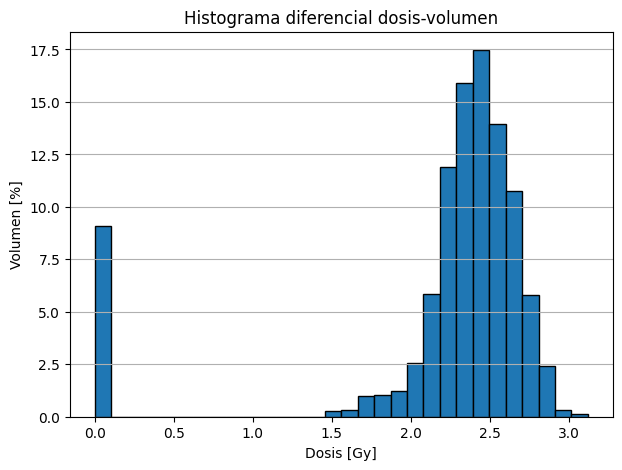

In [4]:
tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [5]:
print(np.std(data_dosis_fisica)/np.mean(data_dosis_fisica))

0.3321978849523046


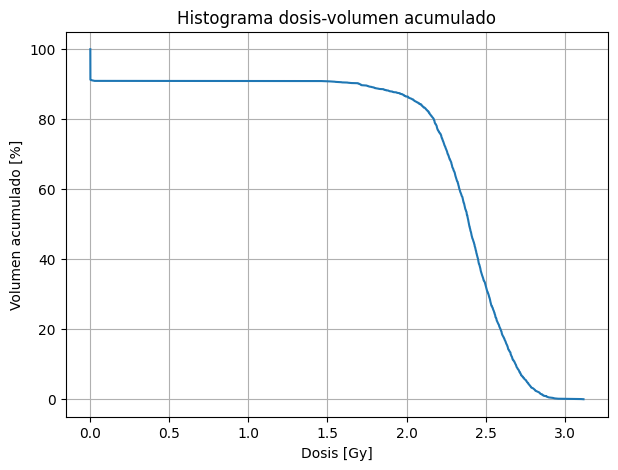

In [6]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

In [7]:
# ─────────────────────────────────────────────
# Índice de homogeneidad: (D2 - D98) / D2
# ─────────────────────────────────────────────

dosis_gy = dosis_ordenada * tiempo_seg  # dosis en Gy (igual que en el plot)

# Invertimos para que np.interp funcione (volumen va de 100 a 0)
vol_inv  = vol_acumulado[::-1]
dosis_inv = dosis_gy[::-1]

D2  = np.interp(2,  vol_inv, dosis_inv)
D98 = np.interp(98, vol_inv, dosis_inv)

HI = (D2 - D98) / D2

print(f"D2  = {D2:.3f} Gy")
print(f"D98 = {D98:.3f} Gy")
print(f"HI  = {HI:.4f}")


D2  = 2.837 Gy
D98 = 0.000 Gy
HI  = 1.0000


Este grafico nos dice qué porcentaje del volumen recibió una dosis mayor o igual que cierto valor :

Por ejemplo:

Dosis ≥ 0.010 Gy/source → 100% del volumen

Dosis ≥ 0.012 Gy/source → 80% del volumen

Dosis ≥ 0.014 Gy/source → 45% del volumen

Dosis ≥ 0.016 Gy/source → 20% del volumen

In [8]:
nx = 16
ny = 10
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 640
Valores leídos: 2112
Ojo: no se leyó la cantidad esperada de bins.


Veo por capas

Filas totales leídas : 2112
Shape               : (2112, 4)

Capa z=1 → z ∈ [98.5300, 98.5800] cm
Vóxeles en la capa : 160
Dosis mín : 0.0000e+00 Gy
Dosis máx : 2.9288e+00 Gy


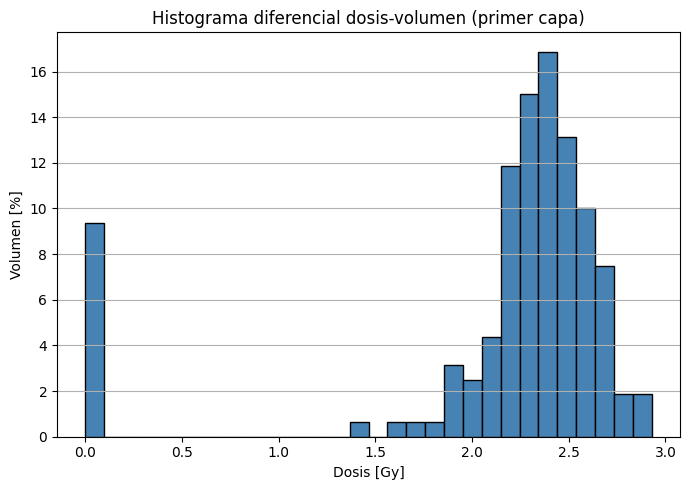

In [10]:
# ── Parámetros del tally ──────────────────────────────────────────
NX, NY, NZ = 16, 10, 4
CAPA_Z = 3          # 0-indexado → 1 = segunda capa

# ── Lector ───────────────────────────────────────────────────────
def leer_dosis_phits_tdeposit(filename):
    filas = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if (linea.startswith("#") or linea.startswith("'") or
                        linea.startswith("ms") or linea.startswith("wt") or
                        linea.startswith("\\") or linea.startswith("e:")):
                    leyendo_tabla = False
                    continue

                partes = linea.split()
                if len(partes) == 4:
                    try:
                        filas.append([float(p) for p in partes])
                    except ValueError:
                        pass

    return np.array(filas)   # shape: (NX*NY*NZ, 4) → columnas: z_low z_up dose rerr


# ── Lectura ───────────────────────────────────────────────────────
file_path = "histograma_dosis_L.out"
tabla = leer_dosis_phits_tdeposit(file_path)

print(f"Filas totales leídas : {len(tabla)}")
print(f"Shape               : {tabla.shape}")

# ── Extraer SÓLO la segunda capa en Z ────────────────────────────
# PHITS organiza con z como índice más interno (x → y → z)
# → los vóxeles de z=1 están en filas 1, 5, 9, ... (cada NZ filas)
indices_capa2 = np.arange(CAPA_Z, NX * NY * NZ, NZ)
capa2 = tabla[indices_capa2]          # shape (160, 4)

z_low = capa2[0, 0]
z_up  = capa2[0, 1]
print(f"\nCapa z=1 → z ∈ [{z_low:.4f}, {z_up:.4f}] cm")
print(f"Vóxeles en la capa : {len(capa2)}")   # debe dar 160

# ── Dosis física ──────────────────────────────────────────────────
tiempo_seg = 300
dosis_fisica = capa2[:, 2] * tiempo_seg   # columna 2 = dose


print(f"Dosis mín : {dosis_fisica.min():.4e} Gy")
print(f"Dosis máx : {dosis_fisica.max():.4e} Gy")

# ── DVH diferencial ───────────────────────────────────────────────
n_voxeles  = len(dosis_fisica)
vol_voxel  = 100.0 / n_voxeles           # % por vóxel

bins_dosis = 30

vol_por_intervalo, bordes = np.histogram(
    dosis_fisica,
    bins=bins_dosis,
    weights=np.ones(n_voxeles) * vol_voxel
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos  = np.diff(bordes)

plt.figure(figsize=(7, 5))
plt.bar(centros, vol_por_intervalo, width=anchos,
        align="center", edgecolor="black", color="steelblue")

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen (primer capa)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

Saco todo lo que no es gel

In [11]:
archivo = "histograma_dosis_L.out"

nx = 16
ny = 33
nz = 4

xmin, xmax = -0.8, 0.8
ymin, ymax = -1.65, 1.65
zmin, zmax = 98.38, 98.58

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

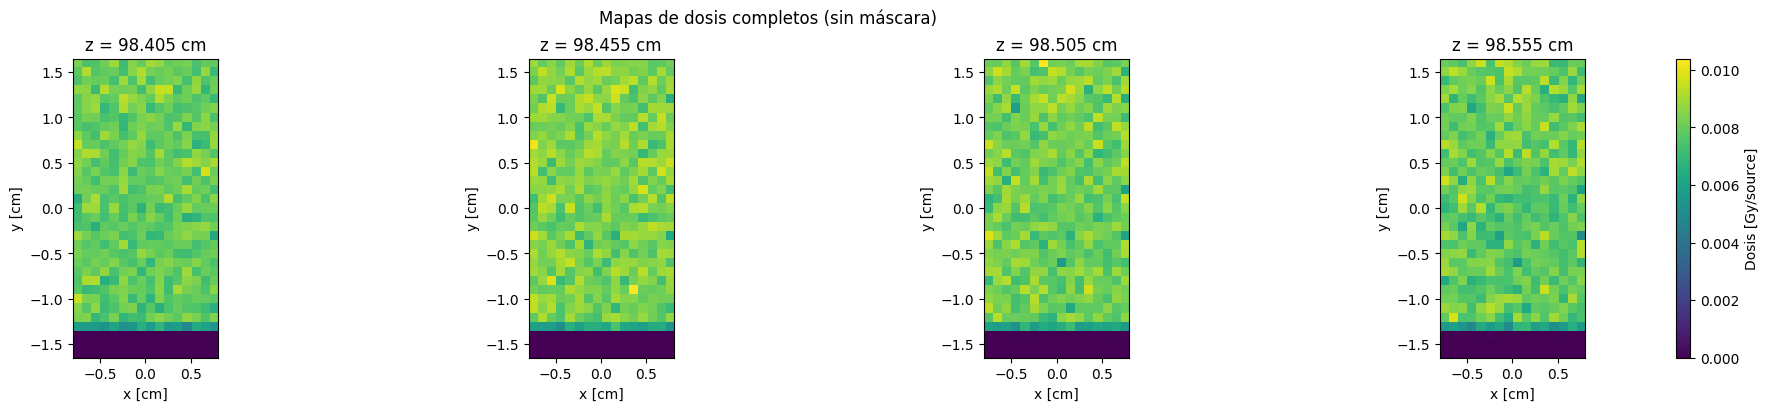

In [12]:
# ==========================================================
# MAPAS DE DOSIS SIN MÁSCARA
# ==========================================================

vmin = np.nanmin(dosis)
vmax = np.nanmax(dosis)

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

for iz in range(nz):

    im = axes[iz].imshow(
        dosis[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Mapas de dosis completos (sin máscara)")
plt.show()

In [13]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0

zmin_pouch = 98.38
zmax_pouch = 98.58
z0 = 0.5 * (zmin_pouch + zmax_pouch)

rx = 0.8
ry = 1.6
rz = 1.0

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin_pouch) & (Z <= zmax_pouch)

mascara_pouch = mascara_elipsoide & mascara_z

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis2 = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

In [14]:
import pandas as pd

print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 300

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis2 = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica2 = data_dosis2 * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis2))
print("Dosis mínima dentro del pouch [Gy/source]:", np.min(data_dosis2))
print("Dosis máxima dentro del pouch [Gy/source]:", np.max(data_dosis2))
print("Dosis mínima dentro del pouch [Gy]:", np.min(data_dosis_fisica2))
print("Dosis máxima dentro del pouch [Gy]:", np.max(data_dosis_fisica2))
print("Dosis media dentro del pouch [Gy]:", np.mean(data_dosis_fisica2))

datos = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datos.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosis[ix, iy, iz],
                    dosis[ix, iy, iz] * tiempo_seg,
                    err_rel[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datos,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head()

z_centros:
[98.405 98.455 98.505 98.555]
Máscara pouch en la primera capa z:
[[False False False False False False False False False False False  True
   True  True  True  True  True  True  True  True  True  True False False
  False False False False False False False False False]
 [False False False False False False False  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True False False False False False False False]
 [False False False False False  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True False False False False False]
 [False False False  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  Tr

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.008291,2.48739,0.0735
1,1,12,2,-0.75,-0.5,98.455,0.009098,2.72952,0.0750
2,1,12,3,-0.75,-0.5,98.505,0.008435,2.53053,0.0819
3,1,12,4,-0.75,-0.5,98.555,0.008438,2.53128,0.0906
4,1,13,1,-0.75,-0.4,98.405,0.008182,2.45472,0.0751


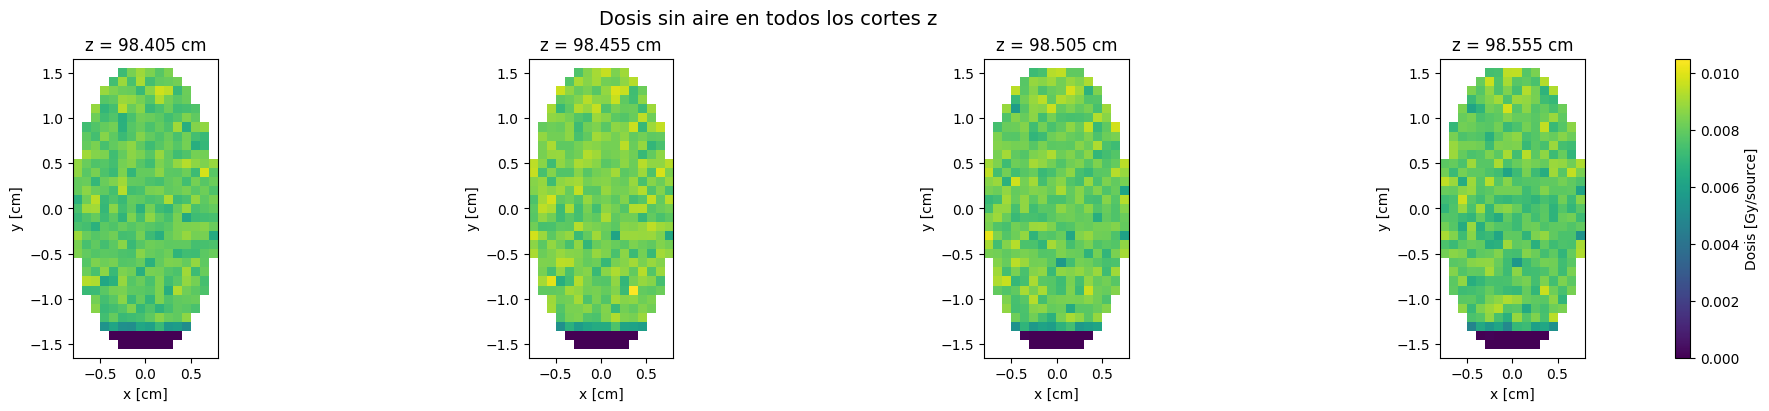

In [ ]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aire)
vmax = np.nanmax(dosis_sin_aire)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

Saco voxeles baja dosis

In [ ]:
ix_sacar = [0]
iy_sacar = [1,2,3]

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)
mascara_sacar[ix_sacar, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar

print("Vóxeles sacados:", np.sum(mascara_sacar))
print("Vóxeles pouch final:", np.sum(mascara_pouch))

Vóxeles sacados: 12
Vóxeles pouch final: 1616


In [ ]:
mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin) & (Z <= zmax)

mascara_pouch = mascara_elipsoide & mascara_z

ix_sacar = [0]
iy_sacar = [1,2,3]

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)
mascara_sacar[ix_sacar, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar

print("Cantidad de voxeles dentro del pouch:", np.sum(mascara_pouch))

Cantidad de voxeles dentro del pouch: 1616


In [ ]:
dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

AGREGAR MAPA BIDIM SIN GEL NI REGION BAJA DOSIS

Cantidad de vóxeles usados: 2112
Dosis mínima [Gy]: 0.0
Dosis máxima [Gy]: 3.2139
Dosis media [Gy]: 2.1922033119446023
Desvío estándar [Gy]: 0.729780267182364
Coeficiente de variación [%]: 33.28980771108358


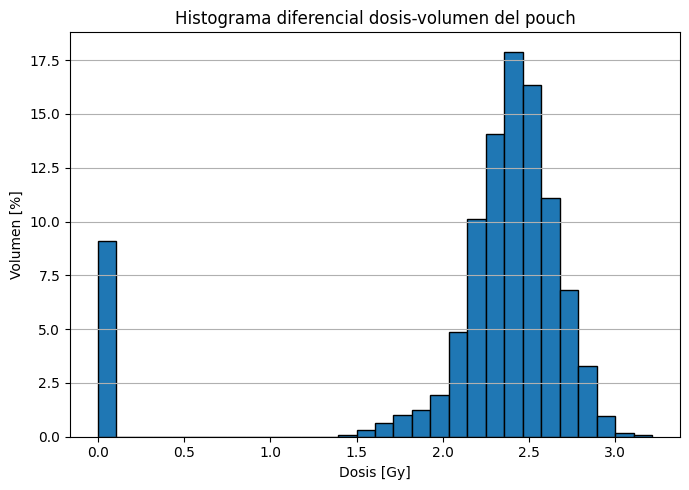

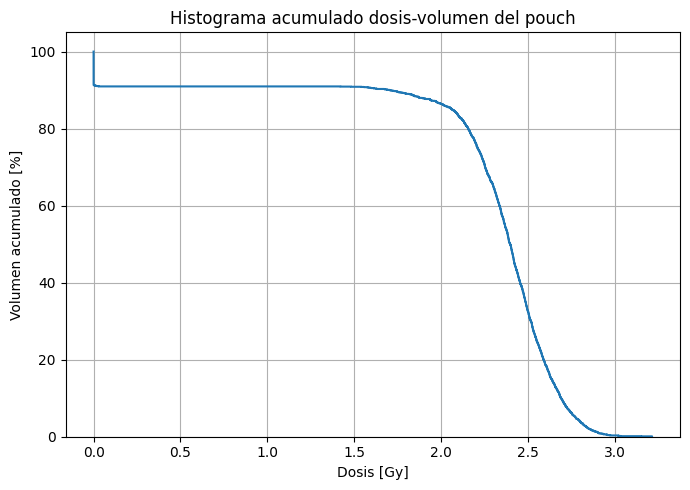

In [ ]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

media = np.mean(data_dosis_fisica)
desvio = np.std(data_dosis_fisica)
cv = 100 * desvio / media

print("Cantidad de vóxeles usados:", n_voxeles)
print("Dosis mínima [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima [Gy]:", np.max(data_dosis_fisica))
print("Dosis media [Gy]:", media)
print("Desvío estándar [Gy]:", desvio)
print("Coeficiente de variación [%]:", cv)

bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

dosis_ordenada = np.sort(data_dosis_fisica)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenada,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")
plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

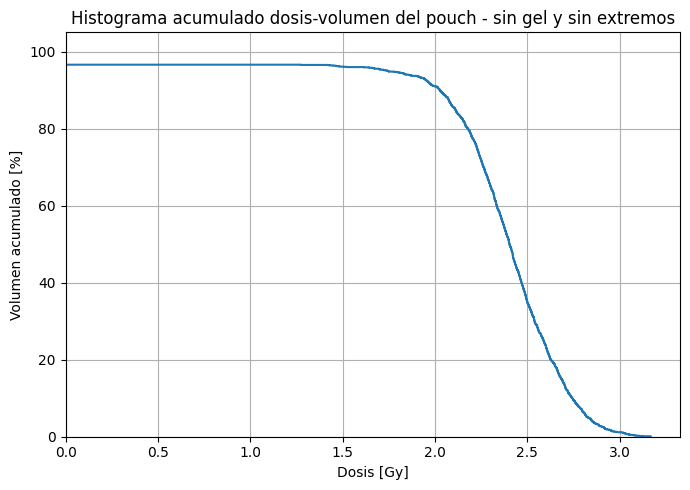

In [ ]:
dosis_ordenada = np.sort(data_dosis_fisica)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

dosis_acum_plot = np.concatenate(([0.0], dosis_ordenada))
volumen_acum_plot = np.concatenate(([100.0], volumen_acumulado))

plt.figure(figsize=(7, 5))

plt.step(
    dosis_acum_plot,
    volumen_acum_plot,
    where="post"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch - sin gel y sin extremos")
plt.grid(True)
plt.xlim(0, np.max(data_dosis_fisica) * 1.05)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [ ]:
media = np.mean(data_dosis_fisica)
desvio = np.std(data_dosis_fisica)
cv = 100 * desvio / media
print("Coeficiente de variación [%]:", cv)


Coeficiente de variación [%]: 22.066474872616123


############################################################

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_L.out"

data_dosis1L = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis1L))
print("Dosis mínima:", np.min(data_dosis1L))
print("Dosis máxima:", np.max(data_dosis1L))
print("Primeros valores:", data_dosis1L[:10])

Cantidad de valores leídos: 2112
Dosis mínima: 0.0
Dosis máxima: 0.010397
Primeros valores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [3]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [4]:
file_path = "histograma_dosis_L.out"
mostrar_encabezados_phits(file_path)
data_dosis1L = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis1L))
print("Dosis mínima:", np.min(data_dosis1L))
print("Dosis máxima:", np.max(data_dosis1L))
print("Primeros valores:", data_dosis1L[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

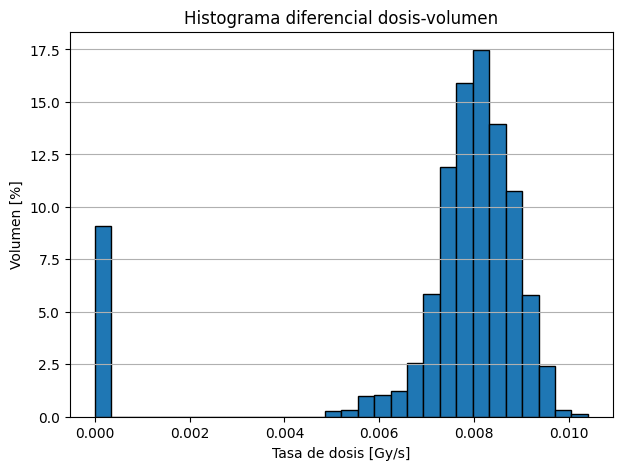

In [5]:
tiempo_seg = 1
data_dosis_fisica1L = data_dosis1L * tiempo_seg

n_bins = len(data_dosis_fisica1L)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica1L,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica1L) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [6]:
np.std(data_dosis1L)/np.mean(data_dosis1L)
print(f"Coeficiente de variación sin sacar nada: {100*np.std(data_dosis1L)/np.mean(data_dosis1L):.2f}%")

Coeficiente de variación sin sacar nada: 33.22%


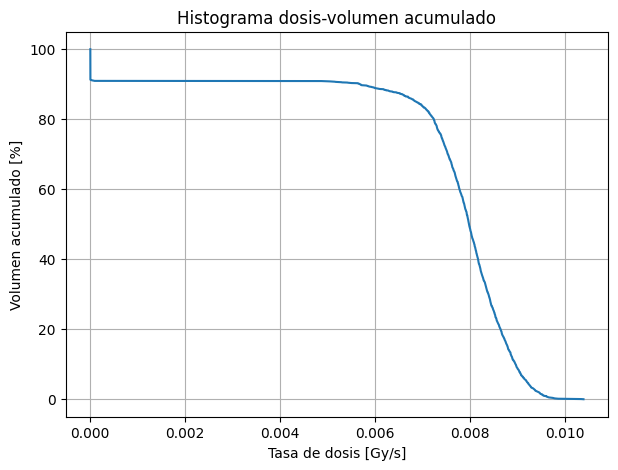

In [7]:
n_bins = len(data_dosis1L)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis1L) * volumen_por_bin

dosis_ordenada1L = np.sort(data_dosis1L)

vol_acumulado1 = np.array([
    np.sum(volumen_total[data_dosis1L >= d])
    for d in dosis_ordenada1L
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada1L*tiempo_seg, vol_acumulado1)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

In [8]:
archivo = "histograma_dosis_L.out"

nx = 16
ny = 33
nz = 4

xmin, xmax = -0.8, 0.8
ymin, ymax = -1.65, 1.65
zmin, zmax = 98.38, 98.58

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

dosisL = np.full((nx, ny, nz), np.nan)
err_relL = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosisL = float(partes[2])
            valor_errL = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosisL[ix_actual, iy_actual, contador_z] = valor_dosisL
            err_relL[ix_actual, iy_actual, contador_z] = valor_errL
            contador_z += 1

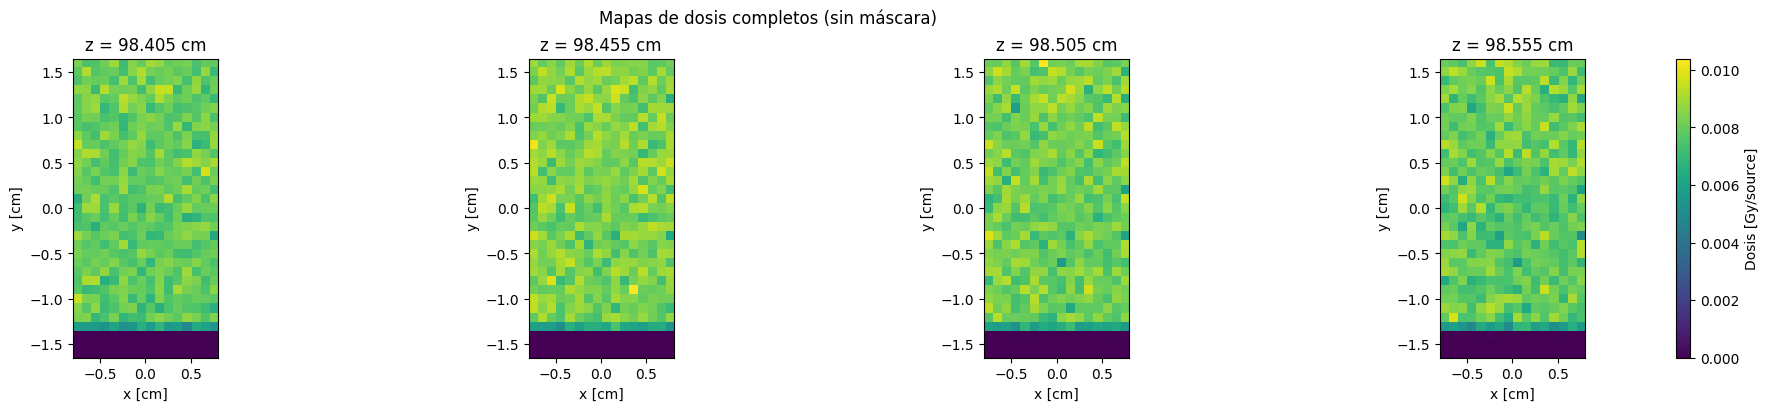

In [9]:
# ==========================================================
# MAPAS DE DOSIS SIN MÁSCARA
# ==========================================================

vmin = np.nanmin(dosisL)
vmax = np.nanmax(dosisL)

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

for iz in range(nz):

    im = axes[iz].imshow(
        dosisL[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Mapas de dosis completos (sin máscara)")
plt.show()

In [10]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0

zmin_pouch = 98.38
zmax_pouch = 98.58
z0 = 0.5 * (zmin_pouch + zmax_pouch)

rx = 0.8
ry = 1.65
rz = 1.0

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin_pouch) & (Z <= zmax_pouch)

mascara_pouch = mascara_elipsoide & mascara_z

dosis_sin_aireL = np.where(mascara_pouch, dosisL, np.nan)
err_sin_aireL = np.where(mascara_pouch, err_relL, np.nan)

data_dosis2L = dosis_sin_aireL[~np.isnan(dosis_sin_aireL)]

In [11]:
import pandas as pd

print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 1

dosis_sin_aireL = np.where(mascara_pouch, dosisL, np.nan)
err_sin_aireL = np.where(mascara_pouch, err_relL, np.nan)

data_dosis2L = dosis_sin_aireL[~np.isnan(dosis_sin_aireL)]
data_dosis_fisica2L = data_dosis2L * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis2L))
print("Dosis mínima dentro del pouch [Gy/s]:", np.min(data_dosis2L))
print("Dosis máxima dentro del pouch [Gy/s]:", np.max(data_dosis2L))
print("Dosis media dentro del pouch [Gy/s]:", np.mean(data_dosis2L))

datosL = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datosL.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosisL[ix, iy, iz],
                    dosisL[ix, iy, iz] * tiempo_seg,
                    err_relL[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datosL,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head()

z_centros:
[98.405 98.455 98.505 98.555]
Máscara pouch en la primera capa z:
[[False False False False False False False False False False False  True
   True  True  True  True  True  True  True  True  True  True False False
  False False False False False False False False False]
 [False False False False False False False  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True False False False False False False False]
 [False False False False False  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True False False False False False]
 [False False False  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  Tr

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.008291,0.008291,0.0735
1,1,12,2,-0.75,-0.5,98.455,0.009098,0.009098,0.0750
2,1,12,3,-0.75,-0.5,98.505,0.008435,0.008435,0.0819
3,1,12,4,-0.75,-0.5,98.555,0.008438,0.008438,0.0906
4,1,13,1,-0.75,-0.4,98.405,0.008182,0.008182,0.0751


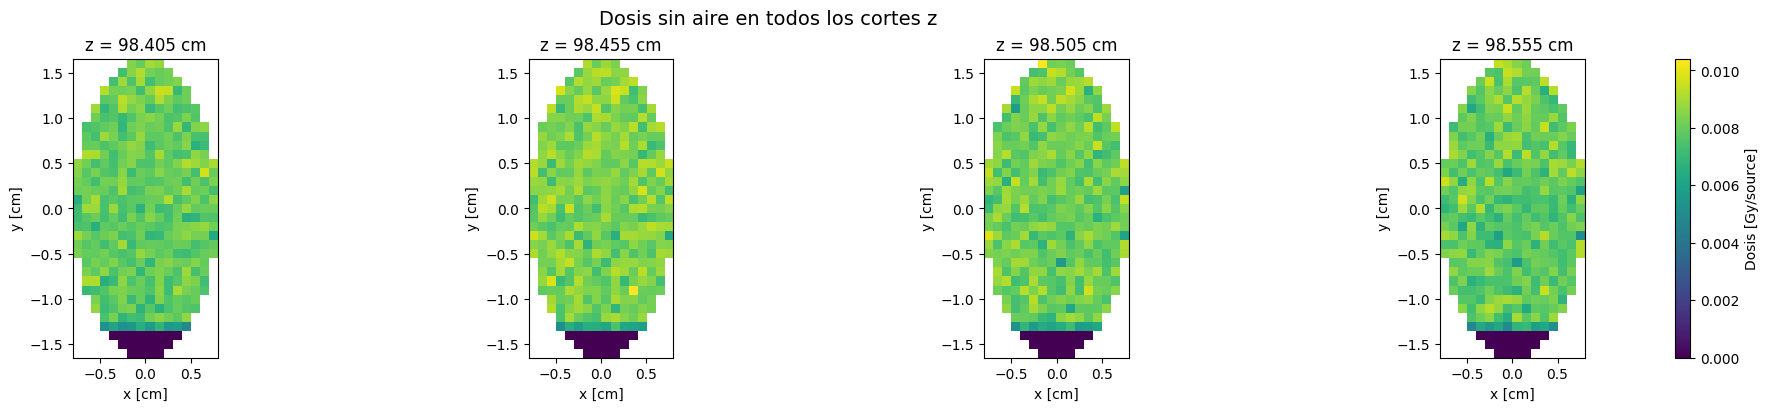

In [12]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aireL)
vmax = np.nanmax(dosis_sin_aireL)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aireL[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

In [13]:
ix_sacar = [0]
iy_sacar = [1,2,3]

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)
mascara_sacar[ix_sacar, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar

print("Vóxeles sacados:", np.sum(mascara_sacar))
print("Vóxeles pouch final:", np.sum(mascara_pouch))

Vóxeles sacados: 12
Vóxeles pouch final: 1648


In [14]:
mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin) & (Z <= zmax)

mascara_pouch = mascara_elipsoide & mascara_z

iy_sacar = [0,1,2,3]   # o [0,1,2,3]

mascara_sacar = np.zeros_like(mascara_pouch, dtype=bool)

mascara_sacar[:, iy_sacar, :] = True

mascara_pouch = mascara_pouch & ~mascara_sacar


print("Cantidad de voxeles dentro del pouch:", np.sum(mascara_pouch))

Cantidad de voxeles dentro del pouch: 1536


In [15]:
dosis_sin_aireL = np.where(mascara_pouch, dosisL, np.nan)
err_sin_aireL = np.where(mascara_pouch, err_relL, np.nan)

data_dosisL = dosis_sin_aireL[~np.isnan(dosis_sin_aireL)]
data_dosis_fisicaL = data_dosisL * tiempo_seg

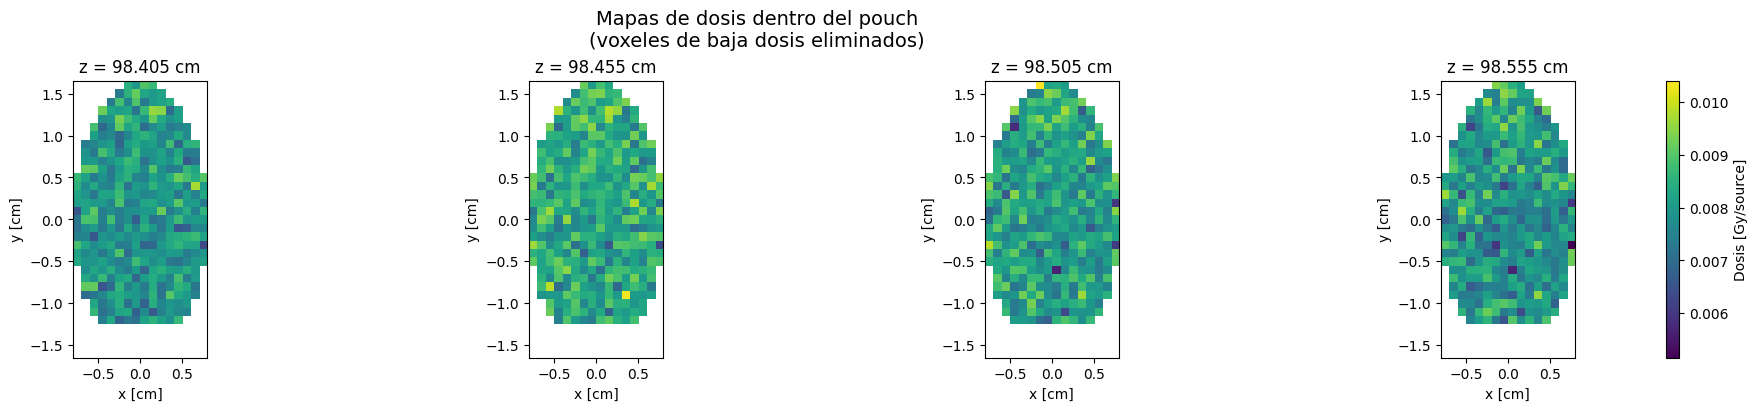

In [16]:
# ==========================================================
# MAPAS DE DOSIS CON LOS VOXELES DE BAJA DOSIS ELIMINADOS
# ==========================================================

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aireL)
vmax = np.nanmax(dosis_sin_aireL)

for iz in range(nz):

    im = axes[iz].imshow(
        dosis_sin_aireL[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm"
    )

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle(
    "Mapas de dosis dentro del pouch\n(voxeles de baja dosis eliminados)",
    fontsize=14
)

plt.show()

Cantidad de vóxeles usados: 1536
Dosis mínima [Gy]: 0.0051554
Dosis máxima [Gy]: 0.010397
Dosis media [Gy]: 0.008092523958333334
Desvío estándar [Gy]: 0.0006856665524566362
Coeficiente de variación [%]: 8.472839326605468


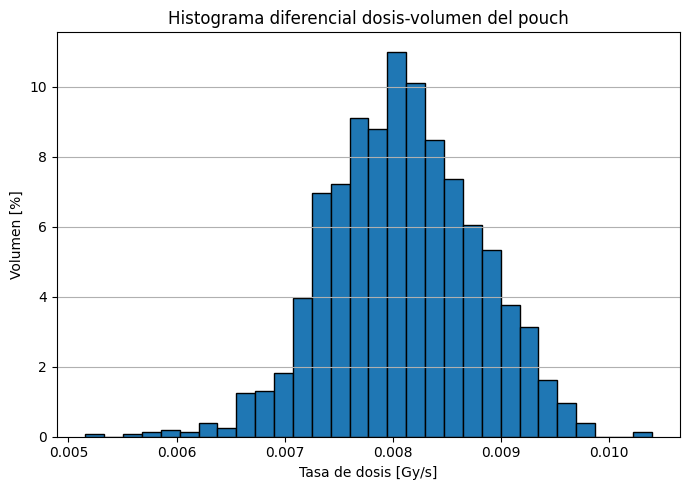

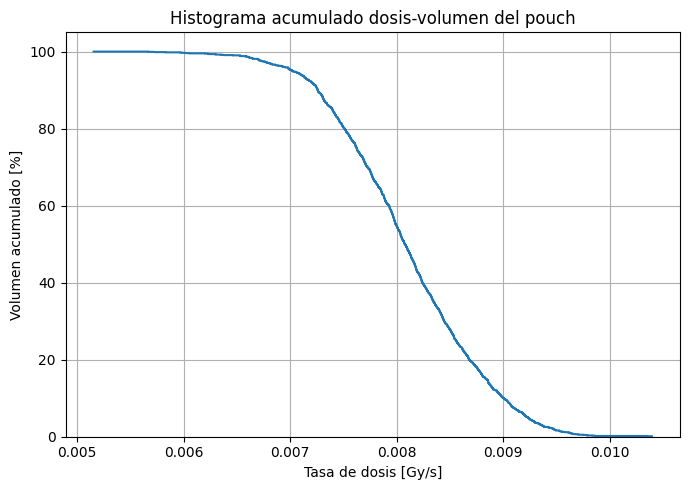

In [17]:
n_voxeles = len(data_dosis_fisicaL)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

media = np.mean(data_dosis_fisicaL)
desvio = np.std(data_dosis_fisicaL)
cv = 100 * desvio / media

print("Cantidad de vóxeles usados:", n_voxeles)
print("Dosis mínima [Gy]:", np.min(data_dosis_fisicaL))
print("Dosis máxima [Gy]:", np.max(data_dosis_fisicaL))
print("Dosis media [Gy]:", media)
print("Desvío estándar [Gy]:", desvio)
print("Coeficiente de variación [%]:", cv)

bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisicaL,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisicaL) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

dosis_ordenadaL = np.sort(data_dosis_fisicaL)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenadaL,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")
plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Cantidad de vóxeles usados: 1536
Dosis mínima [Gy/(s·nA)]: 0.0051554
Dosis máxima [Gy/(s·nA)]: 0.010397
Dosis media [Gy/(s·nA)]: 0.008092523958333334
Desvío estándar [Gy/(s·nA)]: 0.0006856665524566362
Coeficiente de variación [%]: 8.472839326605468


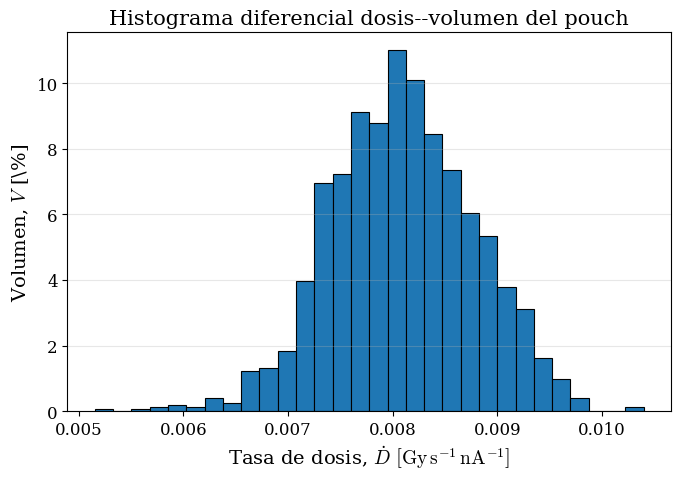

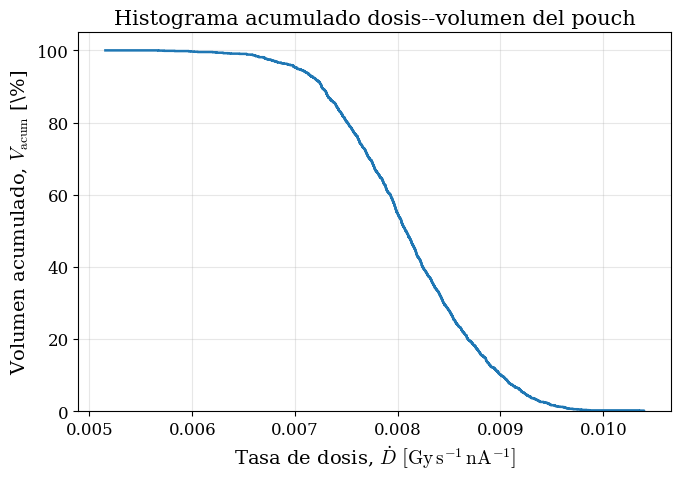

In [20]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

n_voxeles = len(data_dosis_fisicaL)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

media = np.mean(data_dosis_fisicaL)
desvio = np.std(data_dosis_fisicaL)
cv = 100 * desvio / media

print("Cantidad de vóxeles usados:", n_voxeles)
print("Dosis mínima [Gy/(s·nA)]:", np.min(data_dosis_fisicaL))
print("Dosis máxima [Gy/(s·nA)]:", np.max(data_dosis_fisicaL))
print("Dosis media [Gy/(s·nA)]:", media)
print("Desvío estándar [Gy/(s·nA)]:", desvio)
print("Coeficiente de variación [%]:", cv)

bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisicaL,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisicaL) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel(
    r"Tasa de dosis, $\dot{D}$ "
    r"$\left[\mathrm{Gy}\,\mathrm{s}^{-1}\,\mathrm{nA}^{-1}\right]$"
)
plt.ylabel(r"Volumen, $V$ [\%]")
plt.title(r"Histograma diferencial dosis--volumen del pouch")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

dosis_ordenadaL = np.sort(data_dosis_fisicaL)

volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenadaL,
    volumen_acumulado,
    where="post",
    linewidth=1.8
)

plt.xlabel(
    r"Tasa de dosis, $\dot{D}$ "
    r"$\left[\mathrm{Gy}\,\mathrm{s}^{-1}\,\mathrm{nA}^{-1}\right]$"
)
plt.ylabel(r"Volumen acumulado, $V_{\mathrm{acum}}$ [\%]")
plt.title(r"Histograma acumulado dosis--volumen del pouch")
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

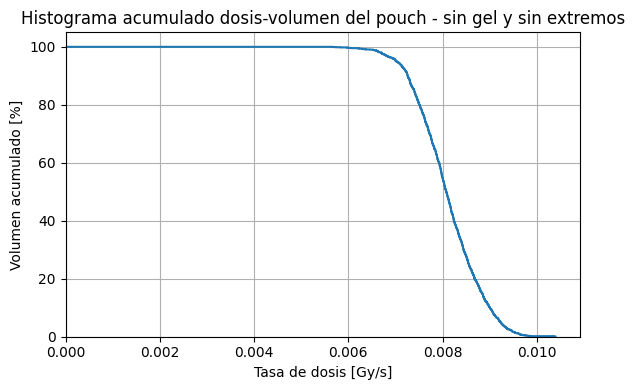

In [ ]:
n_voxeles = len(data_dosis_fisicaL)

dosis_ordenadaL = np.sort(data_dosis_fisicaL)
volumen_acumulado = 100.0 * (1.0 - np.arange(n_voxeles) / n_voxeles)

dosis_acum_plotL = np.concatenate(([0.0], dosis_ordenadaL))
volumen_acum_plot = np.concatenate(([100.0], volumen_acumulado))

plt.figure(figsize=(6, 4))

plt.step(
    dosis_acum_plotL,
    volumen_acum_plot,
    where="post"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch ")
plt.grid(True)
plt.xlim(0, np.max(data_dosis_fisicaL) * 1.05)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

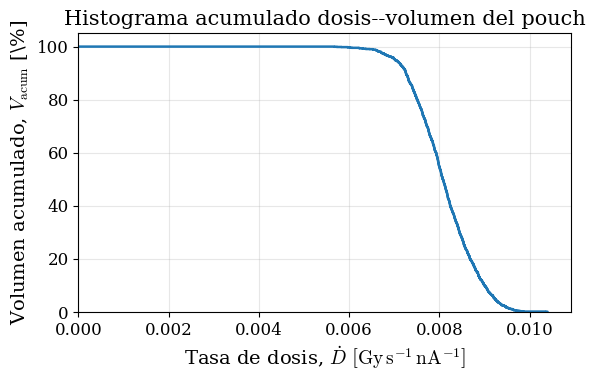

In [21]:

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

n_voxeles = len(data_dosis_fisicaL)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

dosis_ordenadaL = np.sort(data_dosis_fisicaL)

volumen_acumulado = 100.0 * (
    1.0 - np.arange(n_voxeles) / n_voxeles
)

dosis_acum_plotL = np.concatenate((
    [0.0],
    dosis_ordenadaL
))

volumen_acum_plot = np.concatenate((
    [100.0],
    volumen_acumulado
))

plt.figure(figsize=(6, 4))

plt.step(
    dosis_acum_plotL,
    volumen_acum_plot,
    where="post",
    linewidth=1.8
)

plt.xlabel(
    r"Tasa de dosis, $\dot{D}$ "
    r"$\left[\mathrm{Gy}\,\mathrm{s}^{-1}\,\mathrm{nA}^{-1}\right]$"
)

plt.ylabel(
    r"Volumen acumulado, $V_{\mathrm{acum}}$ [\%]"
)

plt.title(
    r"Histograma acumulado dosis--volumen del pouch"
)

plt.grid(True, alpha=0.3)
plt.xlim(0, np.max(data_dosis_fisicaL) * 1.05)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [19]:
print(f"Dosis máxima = {np.max(dosis_ordenadaL ):.5f}Gy/s")
print(f"Dosis media = {np.mean(dosis_ordenadaL ):.5f}Gy/s")

Dosis máxima = 0.01040Gy/s
Dosis media = 0.00809Gy/s
